<a href="https://colab.research.google.com/github/njwbilll/midterm-machine-learning/blob/main/2_regresi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install optuna mlflow lime -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import optuna
import mlflow
import mlflow.sklearn
import lime
import lime.lime_tabular

print("✅ Semua library berhasil diimport!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.7 MB/s eta 0:00:00
   ━━━

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

BASE_PATH = '/content/drive/MyDrive/ML Dataset/'

print("Loading dataset...")
df = pd.read_csv(BASE_PATH + 'midterm-regresi-dataset.csv', header=None)

# Rename kolom
df.columns = ['year'] + [f'feature_{i}' for i in range(1, 91)]

print(f"✅ Shape: {df.shape}")
print(f"\nTarget (year) stats:")
print(df['year'].describe())

Mounted at /content/drive
Loading dataset...
✅ Shape: (515345, 91)

Target (year) stats:
count    515345.000000
mean       1998.397082
std          10.931046
min        1922.000000
25%        1994.000000
50%        2002.000000
75%        2006.000000
max        2011.000000
Name: year, dtype: float64


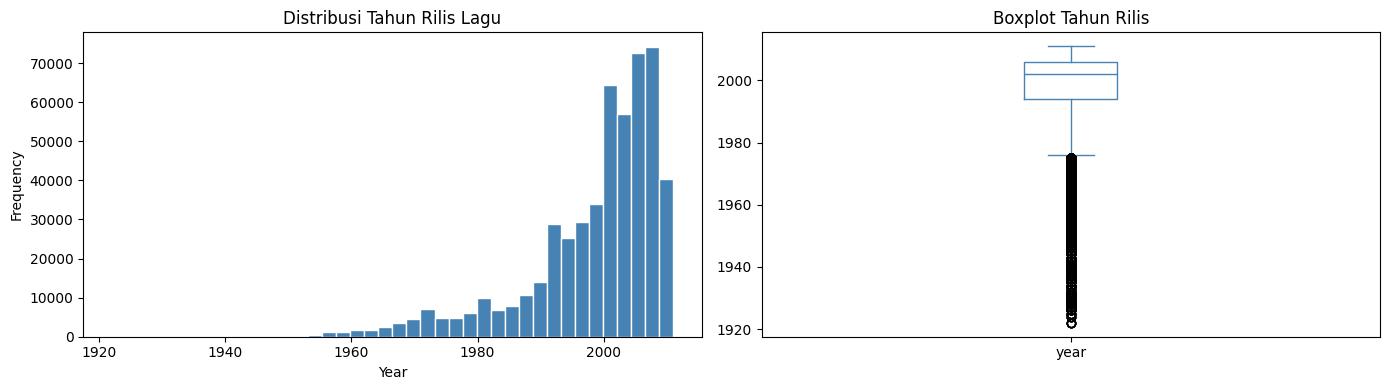


Tahun paling tua : 1922
Tahun paling baru: 2011
Missing values   : 0


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribusi tahun
df['year'].plot(kind='hist', bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Tahun Rilis Lagu')
axes[0].set_xlabel('Year')

# Boxplot tahun
df['year'].plot(kind='box', ax=axes[1], color='steelblue')
axes[1].set_title('Boxplot Tahun Rilis')

plt.tight_layout()
plt.show()

print(f"\nTahun paling tua : {df['year'].min()}")
print(f"Tahun paling baru: {df['year'].max()}")
print(f"Missing values   : {df.isnull().sum().sum()}")

In [ ]:
# Pisahkan fitur dan target
X = df.drop(columns=['year'])
y = df['year']

feature_names = X.columns.tolist()

# Split data
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train: {X_train.shape}")
print(f"X_val  : {X_val.shape}")

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

print("✅ Preprocessing selesai!")

X_train: (412276, 90)
X_val  : (103069, 90)
✅ Preprocessing selesai!


In [ ]:
def evaluate(model_name, y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    print(f"\n{'='*40}")
    print(f"  {model_name}")
    print(f"{'='*40}")
    print(f"  MSE  : {mse:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")
    print(f"{'='*40}")

    return {'model': model_name, 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

results = []  # Simpan semua hasil di sini

In [ ]:
mlflow.set_experiment("SongYear_Regression")

with mlflow.start_run(run_name="Ridge_Baseline"):
    ridge = Ridge(alpha=1.0)
    ridge.fit(X_train_scaled, y_train)

    y_pred_ridge = ridge.predict(X_val_scaled)
    metrics = evaluate("Ridge Regression", y_val, y_pred_ridge)
    results.append(metrics)

    mlflow.log_param("alpha", 1.0)
    mlflow.log_metrics({k: v for k, v in metrics.items() if k != 'model'})
    mlflow.sklearn.log_model(ridge, "ridge_model")

print("✅ Ridge selesai!")

2026/05/14 15:57:36 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/14 15:57:36 INFO mlflow.store.db.utils: Updating database tables
2026/05/14 15:57:38 INFO mlflow.tracking.fluent: Experiment with name 'SongYear_Regression' does not exist. Creating a new experiment.
2026/05/14 15:57:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  Ridge Regression
  MSE  : 90.6935
  RMSE : 9.5233
  MAE  : 6.7782
  R²   : 0.2380


2026/05/14 15:57:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Ridge selesai!


In [ ]:
def objective_xgb(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'       : trial.suggest_int('max_depth', 3, 8),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'tree_method'     : 'hist',
        'device'          : 'cuda',
        'random_state'    : 42,
    }

    with mlflow.start_run(run_name=f"XGB_trial_{trial.number}", nested=True):
        model = xgb.XGBRegressor(**params)
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False
        )
        y_pred = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))

        mlflow.log_params(params)
        mlflow.log_metric("val_rmse", rmse)

    return rmse  # Optuna minimize RMSE

print("Mulai Optuna tuning XGBoost (20 trials)...")
optuna.logging.set_verbosity(optuna.logging.WARNING)

with mlflow.start_run(run_name="XGBoost_Optuna"):
    study_xgb = optuna.create_study(direction='minimize')
    study_xgb.optimize(objective_xgb, n_trials=20, show_progress_bar=True)

    print(f"\n✅ Best RMSE : {study_xgb.best_value:.4f}")
    print(f"Best params : {study_xgb.best_params}")
    mlflow.log_metric("best_val_rmse", study_xgb.best_value)

Mulai Optuna tuning XGBoost (20 trials)...


  0%|          | 0/20 [00:00<?, ?it/s]


✅ Best RMSE : 8.7060
Best params : {'n_estimators': 440, 'max_depth': 8, 'learning_rate': 0.10162738868392897, 'subsample': 0.92999358541519, 'colsample_bytree': 0.8413724383436558, 'min_child_weight': 4}


Training final XGBoost...


2026/05/14 16:02:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/14 16:02:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



  XGBoost (Tuned)
  MSE  : 75.7942
  RMSE : 8.7060
  MAE  : 6.0893
  R²   : 0.3632


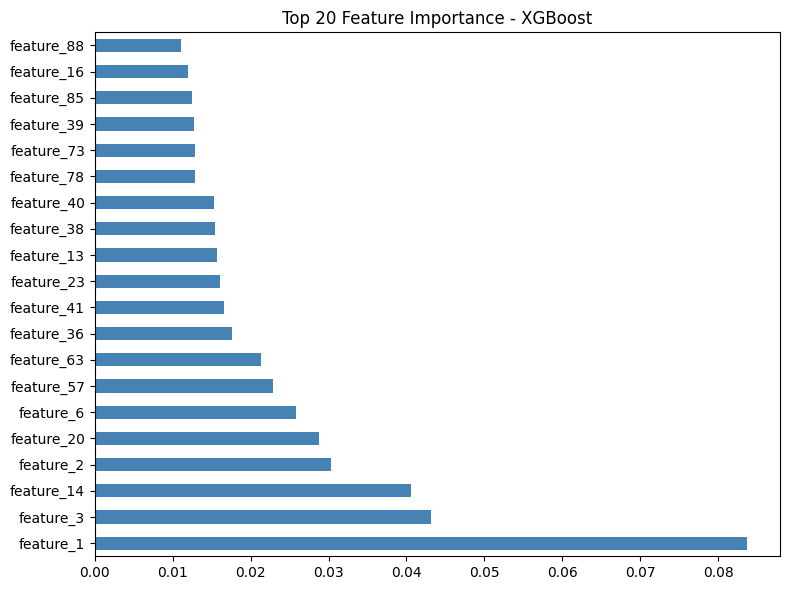

In [ ]:
best_params = study_xgb.best_params
best_params.update({
    'tree_method' : 'hist',
    'device'      : 'cuda',
    'random_state': 42
})

print("Training final XGBoost...")
final_xgb = xgb.XGBRegressor(**best_params)
final_xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

y_pred_xgb = final_xgb.predict(X_val)
metrics_xgb = evaluate("XGBoost (Tuned)", y_val, y_pred_xgb)
results.append(metrics_xgb)

with mlflow.start_run(run_name="XGBoost_Final"):
    mlflow.log_params(best_params)
    mlflow.log_metrics({k: v for k, v in metrics_xgb.items() if k != 'model'})
    mlflow.sklearn.log_model(final_xgb, "xgb_final_model")

# Feature Importance
feat_imp = pd.Series(final_xgb.feature_importances_, index=feature_names)
feat_imp.nlargest(20).plot(kind='barh', figsize=(8, 6), color='steelblue')
plt.title('Top 20 Feature Importance - XGBoost')
plt.tight_layout()
plt.show()

Setup LIME explainer...
Actual year   : 2008
Predicted year: 2005.73


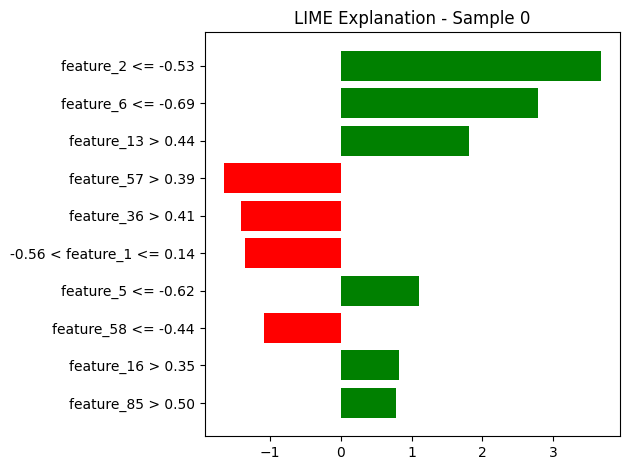


Top 10 fitur yang paling berpengaruh:
  feature_2 <= -0.53                       → +3.6770
  feature_6 <= -0.69                       → +2.7890
  feature_13 > 0.44                        → +1.8151
  feature_57 > 0.39                        → -1.6540
  feature_36 > 0.41                        → -1.4021
  -0.56 < feature_1 <= 0.14                → -1.3507
  feature_5 <= -0.62                       → +1.1065
  feature_58 <= -0.44                      → -1.0827
  feature_16 > 0.35                        → +0.8217
  feature_85 > 0.50                        → +0.7839


In [ ]:
print("Setup LIME explainer...")

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data  = X_train_scaled,
    feature_names  = feature_names,
    mode           = 'regression',
    random_state   = 42
)

# Ambil 1 sample dari validation set untuk dijelaskan
sample_idx = 0
sample     = X_val_scaled[sample_idx]

print(f"Actual year   : {y_val.iloc[sample_idx]}")
print(f"Predicted year: {final_xgb.predict(X_val.iloc[[sample_idx]])[0]:.2f}")

# Generate explanation
# Karena final_xgb butuh unscaled data, kita buat wrapper
def predict_fn(x):
    x_unscaled = scaler.inverse_transform(x)
    return final_xgb.predict(x_unscaled)

exp = explainer.explain_instance(
    data_row       = sample,
    predict_fn     = predict_fn,
    num_features   = 10
)

exp.as_pyplot_figure()
plt.title(f'LIME Explanation - Sample {sample_idx}')
plt.tight_layout()
plt.show()

print("\nTop 10 fitur yang paling berpengaruh:")
for feat, weight in exp.as_list():
    print(f"  {feat:40s} → {weight:+.4f}")


=== PERBANDINGAN SEMUA MODEL ===
           model       MSE     RMSE      MAE       R2
Ridge Regression 90.693471 9.523312 6.778170 0.237966
 XGBoost (Tuned) 75.794174 8.705985 6.089342 0.363155


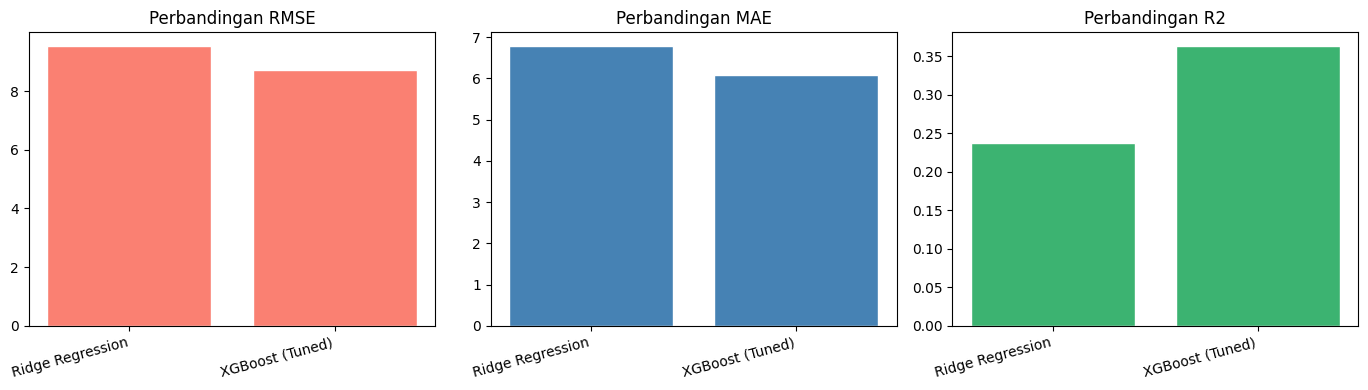

In [ ]:
results_df = pd.DataFrame(results)
print("\n=== PERBANDINGAN SEMUA MODEL ===")
print(results_df.to_string(index=False))

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

metrics_to_plot = ['RMSE', 'MAE', 'R2']
colors = ['salmon', 'steelblue', 'mediumseagreen']

for ax, metric, color in zip(axes, metrics_to_plot, colors):
    ax.bar(results_df['model'], results_df[metric], color=color, edgecolor='white')
    ax.set_title(f'Perbandingan {metric}')
    ax.set_xticklabels(results_df['model'], rotation=15, ha='right')

plt.tight_layout()
plt.show()

In [ ]:
import joblib

SAVE_PATH = '/content/drive/MyDrive/ML Dataset/models/'
import os
os.makedirs(SAVE_PATH, exist_ok=True)

# Simpan model dan scaler
joblib.dump(ridge, SAVE_PATH + 'ridge_model.pkl')
joblib.dump(final_xgb, SAVE_PATH + 'xgb_final.pkl')
joblib.dump(scaler, SAVE_PATH + 'scaler.pkl')

print("✅ Semua model berhasil disimpan ke Drive!")

✅ Semua model berhasil disimpan ke Drive!
